Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("..")
from HelpingFunctions import ERCOTProcessor
from HelpingFunctions import WeatherProcessing
from HelpingFunctions import FeatureEngineering
from HelpingFunctions import ForecastingHelpers

import onnxruntime as ort
ort.set_default_logger_severity(4)
from mapie.regression import MapieRegressor
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 125

In [2]:
# Does not like processing between 2002-2024 in one go, split to allow for optimization
ercot_df_pt1 = ERCOTProcessor.fileprocessing(2002,2016)
ercot_df_pt2 = ERCOTProcessor.fileprocessing(2016,2024)
ercot_df = pd.concat([ercot_df_pt1, ercot_df_pt2])

/home/ortild/Amaranth/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ERCOTProcessor.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ercot_df = ercot_df.asfreq('H', method='pad')
/home/ortild/Amaranth/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ERCOTProcessor.py:23: FutureWarning: Parsed string "11/05/2017 01:00 DST" included an un-recognized timezone "DST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  return pd.to_datetime(str(r)[:11]+'0'+str(h)+str(r)[13:])
/home/ortild/Amaranth/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ERCOTProcessor.py:23: FutureWarning: Parsed string "11/04/2018 01:00 DST" included an un-recognized timezone "DST". Dropping unrecogni

In [3]:
# Process weather data
filename = 'ElectricityDemandAustinTX/LoadForecastingAttacks/Weather/weather_20022024.csv'
weather_df = pd.read_csv(filename).drop('Unnamed: 0', axis=1)
weather_df.columns = ['time', 'temp', 'humd', 'wnsp', 'cond']
weather_df.loc[:,'time'] = weather_df['time'].apply(lambda x: pd.to_datetime(x))
weather_df = weather_df.set_index('time')
weather_df.head()

/home/ortild/.conda/envs/Amaranth/lib/python3.13/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,temp,humd,wnsp,cond
time,,,,
2002-01-01 00:00:00,36.0,0.64,7.0,0.0
2002-01-01 01:00:00,36.0,0.57,8.0,0.0
2002-01-01 02:00:00,36.0,0.57,8.0,0.0
2002-01-01 03:00:00,36.0,0.57,6.0,0.0
2002-01-01 04:00:00,35.0,0.61,8.0,0.0


In [4]:
# Concat weather and ERCOT data and deduplicate any values
full_df = FeatureEngineering.feature_engineering(weather_df, ercot_df)
full_df = full_df.drop_duplicates(subset=None, keep="last", inplace=False)
full_df = full_df[~full_df.index.duplicated()]

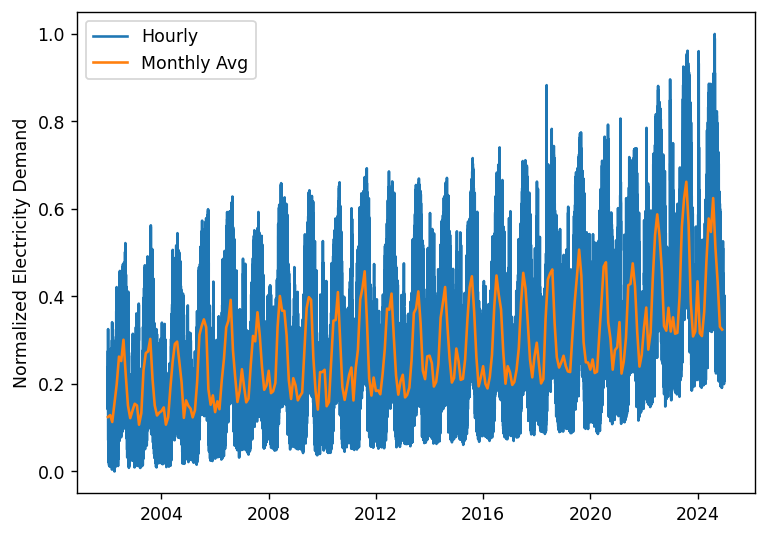

In [5]:
# Plot a monthly rolling average versus the true hourly value
monthly_norm = full_df['load'].resample('MS').mean().bfill()
plt.plot(full_df['load'], label='Hourly')
plt.plot(monthly_norm, label='Monthly Avg')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [6]:
hourly_res_norm = ForecastingHelpers.hourlyresiduals(full_df)

/home/ortild/Amaranth/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ForecastingHelpers.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hourly_res_norm['load'] = df_norm['load'].groupby(pd.Grouper(freq='M')).transform(lambda x: x - x.mean())


In [7]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values
y_test = test['load'].values

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

In [8]:
def compute_mae(y, yhat):
    """given predicted and observed values, computes mean absolute error"""
    return np.mean(np.abs(yhat - y))

def forecast(model, exog, y_init):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = model.predict(Xi_te)[0]
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat.append(model.predict(Xi_te)[0])
    return np.array(yhat)
def weekly_forecast(model, exog, y_init):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        yhat.append(forecast(model, exog_i, yi))
    return np.hstack(yhat)

Random Forest Regression

In [9]:
from sklearn.ensemble import RandomForestRegressor

# train RFR model, and get validation performance
def get_rfr_mae(ne, md):
    mod = RandomForestRegressor(n_estimators=ne, max_depth=md)
    mod.fit(X_tr, y_tr)
    pred_val = weekly_forecast(mod, exog_val, y_init_val)
    return compute_mae(y_val, pred_val)
    
# define potential hyperparameter sets
n_estimators = [5, 8, 10]
max_depth = [4, 5, 6]
grid_search = pd.DataFrame(columns=['ne','md','mae'])

# perform grid search 
for ne in n_estimators:
    for md in max_depth:
        mae = get_rfr_mae(ne, md)
        print(mae)
        params = {'ne':ne, 'md':md, 'mae':mae} 
        params_df = pd.DataFrame([params])
        grid_search = pd.concat([grid_search, params_df], ignore_index=True)
        
# display best hyperparameters based on grid search
grid_rfr = grid_search.sort_values('mae').head(1)


0.06519323707313418


/tmp/ipykernel_734926/1015095527.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grid_search = pd.concat([grid_search, params_df], ignore_index=True)


0.06378682345947374
0.05928402352374046
0.06586432586027229
0.06431213429885978
0.05621924208013074
0.06651432988876038
0.06471354506158278
0.056789742904936456


In [10]:
from mapie.regression import MapieRegressor
import joblib

# best hyperparameters
ne, md = grid_rfr['ne'].values[0], grid_rfr['md'].values[0]

# train model and get predictions
mod_rfr = RandomForestRegressor(n_estimators=ne, max_depth=md)
mod_rfr.fit(X_tr, y_tr)

mapie = MapieRegressor(mod_rfr, method="naive")
mapie.fit(X_tr, y_tr)
pred_mapie, pred_ci = ForecastingHelpers.weekly_forecast(yp_val.index, mapie, exog_val, y_init_val, 0.05)
print('MAE:', ForecastingHelpers.compute_mae(y_val, pred_mapie))

# Save the model
filename = 'ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/RFR.joblib'
joblib.dump(mapie, filename)

MAE: 0.06008028955616549


['ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/RFR.joblib']

In [12]:
#convert to pickle file
import pickle
filename = "ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/rfr_no_mapie_pkl.pkl"
with open(filename, 'wb') as file:
    pickle.dump(mod_rfr, file)

In [11]:
# convert to onnx
from skl2onnx import to_onnx
X_tr32 = X_tr[:1].astype(dtype="float32")

onx = to_onnx(mod_rfr, X_tr32)
with open("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/rfr_no_mapie.onnx", "wb") as f:
    f.write(onx.SerializeToString())

In [12]:
# Predict forecasted values for testing
pred_mapie_te, pred_ci_te = ForecastingHelpers.weekly_forecast(yp_te.index, mapie, exog_te, y_init_te, 0.05)

MAE: 0.06518448806853548


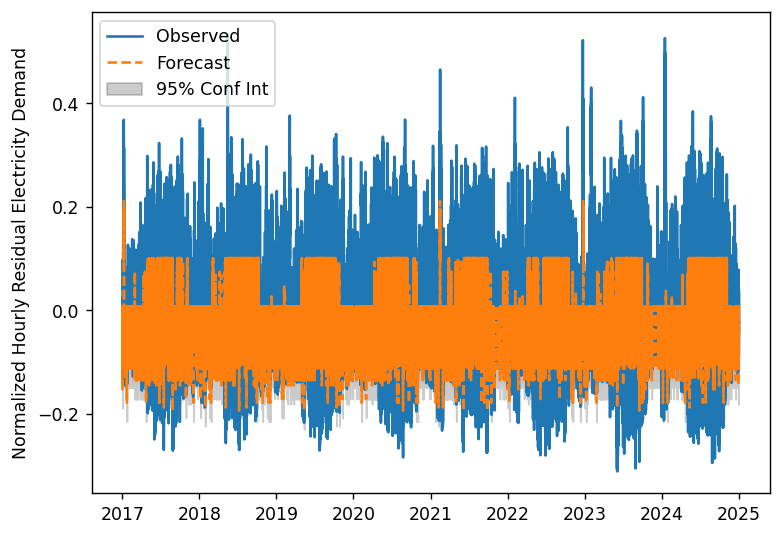

In [13]:
# plot testing
print('MAE:', ForecastingHelpers.compute_mae(yp_te, pred_mapie_te))
ForecastingHelpers.plot_full(yp_te, pred_mapie_te, yp_te.index, pred_ci_te)

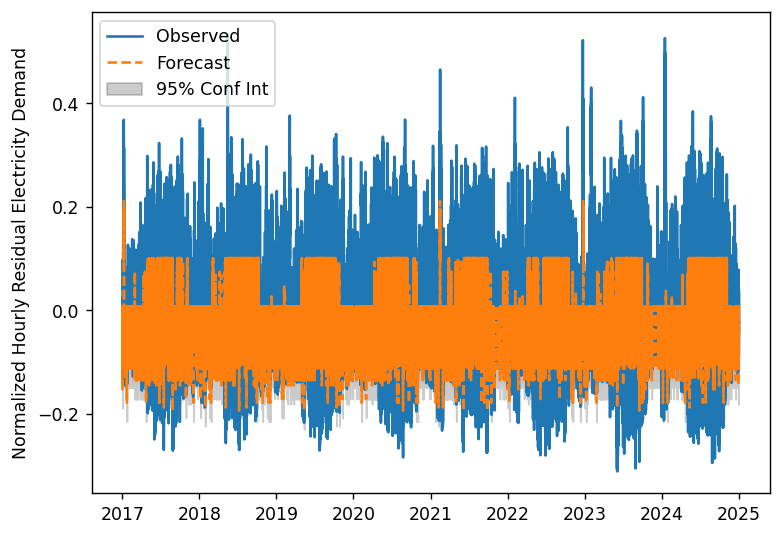

In [14]:
# Convert prediction and confidence interval for validation and testing datasets to Pandas Dataframes 
# to be used to find the deviation of the confidence interval width
pred_df = pd.DataFrame(data=pred_mapie, index=yp_val.index, columns=['load'])
pred_test = pd.DataFrame(data=pred_mapie_te, index=yp_te.index, columns=['load'])
preds_rfr = pd.concat([pred_df, pred_test])
#print(preds_rfr)
ci = pd.concat([pred_ci, pred_ci_te])
preds_np = preds_rfr['load']
normals = pd.concat([yp_val, yp_te])
ForecastingHelpers.plot_full(yp_te, pred_mapie_te, yp_te.index, pred_ci_te)

In [15]:
# Get the confidence interval width (c_x) right after training and validation and compare to the confidence interval width iterated to the point where
# the width of the interval exceeds the width of c_x, labeling it 'div' as the point at which a division happens.
for i, index_label in enumerate(pred_ci_te.index):
        lb = pred_ci_te.iloc[i,0]
        ub = pred_ci_te.iloc[i,1]
        c_x = pred_ci.iloc[-1,1]-pred_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = preds_np[i]
            break
        else:
            div = ci.index[-1]

div

/tmp/ipykernel_363628/2089506598.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  load_div = preds_np[i]


Timestamp('2017-01-01 01:00:00')

In [16]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(yp_te,preds_rfr['load'])
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, yp_te)
med_drift

Timestamp('2017-01-03 20:00:00')

In [17]:
# PSI, which is a deviation of KL divergence can be used to determe drift, it is the symmetric version of KL divergence.
psi = ForecastingHelpers.calculatePSI(yp_te, preds_rfr['load'])
med_PSI, high_PSI = ForecastingHelpers.testPSI(psi, yp_te)
med_PSI

/home/ortild/.conda/envs/Amaranth/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Timestamp('2017-01-04 19:00:00')

In [18]:
print("Exceeds confidence interval: "  + str(ForecastingHelpers.MTTF(pred_df, div)) + " Exceeds 0.1 divergence: " + str(ForecastingHelpers.MTTF(pred_df, med_drift)))

Exceeds confidence interval: 731 days 01:00:00 Exceeds 0.1 divergence: 733 days 20:00:00


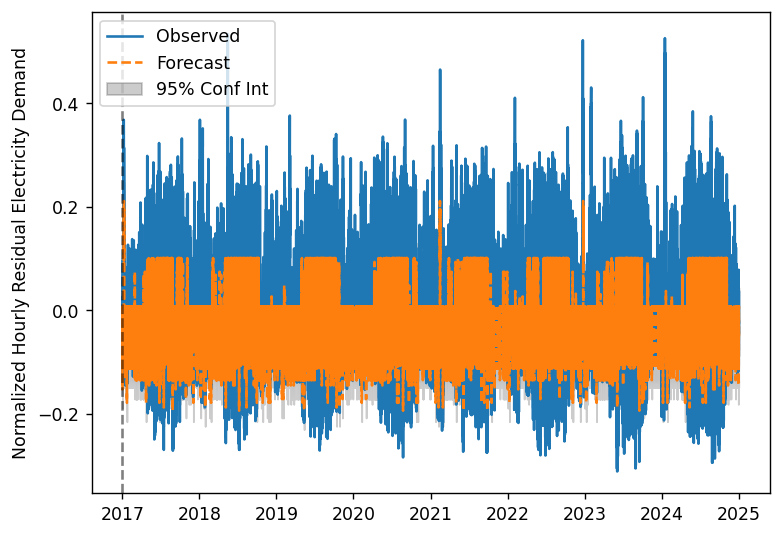

In [19]:
ForecastingHelpers.plot_full_w_div(yp_te, pred_mapie_te, yp_te.index, pred_ci_te, div)

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

load_min, load_max = full_df['load'].min(), full_df['load'].max()
temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()


# best hyperparameters from grid search
best_monthly_order = (1,1,1)
best_monthly_seas_order = (0,1,1,12)


# monthly average forecasts
train_m = monthly_norm[:'2016']
test_m = monthly_norm['2017':]
model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit()
forecast_m = model_m.get_forecast(steps=len(test_m))
pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)

# baseline hourly residual forecasts
idx = test.index[::168]
idx = idx.append(pd.DatetimeIndex(['2017-12-31 23']))
pred_base = pd.Series(np.hstack([y_init_te, yp_te.iloc[-1]]), index=idx)
pred_base = pred_base.resample('H').ffill().values

/home/ortild/.conda/envs/Amaranth/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_363628/579075919.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pred_base = pred_base.resample('H').ffill().values


In [21]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

rfr_norm_df = pd.DataFrame({'h_norm':pred_test['load'], 'month':test.index.month, 'year':test.index.year})
upper_ci_df = pd.DataFrame({'h_norm':pred_ci_te['Upper Bounds'], 'month':test.index.month, 'year':test.index.year})
lower_ci_df = pd.DataFrame({'h_norm':pred_ci_te['Lower Bounds'], 'month':test.index.month, 'year':test.index.year})
pred_rfr_norm_df = rfr_norm_df.merge(m_norm_df, on=['month','year'])
pred_upper_norm_df = upper_ci_df.merge(m_norm_df, on=['month','year'])
pred_lower_norm_df = lower_ci_df.merge(m_norm_df, on=['month','year'])
pred_rfr_norm = pd.Series((pred_rfr_norm_df['m_norm'] + pred_rfr_norm_df['h_norm']).values, index=test.index)
pred_upper_norm = pd.Series((pred_upper_norm_df['m_norm'] + pred_upper_norm_df['h_norm']).values, index=test.index)
pred_lower_norm = pd.Series((pred_lower_norm_df['m_norm'] + pred_lower_norm_df['h_norm']).values, index=test.index)
pred_rfr = pred_rfr_norm * (load_max - load_min) + load_min
pred_upper = pred_upper_norm * (load_max - load_min) + load_min
pred_lower = pred_lower_norm * (load_max - load_min) + load_min

In [22]:
# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_pred = pred_rfr.resample('MS').mean().bfill()

In [23]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift

Timestamp('2019-02-01 00:00:00')

In [24]:
sampled_upper = pred_upper.resample('MS').mean().bfill()
sampled_lower = pred_lower.resample('MS').mean().bfill()

Text(0, 0.5, 'Normalized Electricity Demand')

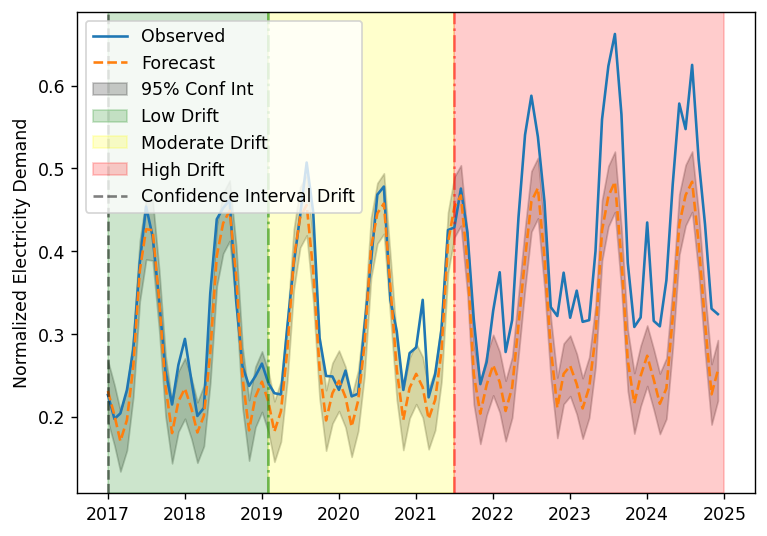

In [25]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(sampled_pred, label='Forecast', ls='--')
plt.fill_between(sampled_upper.index, sampled_lower, sampled_upper,
                 color='k', alpha=0.2, label='95% Conf Int')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(pred_rfr.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_rfr.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.legend()
plt.ylabel('Normalized Electricity Demand')

In [26]:
# Convert prediction and confidence interval for validation and testing datasets to Pandas Dataframes 
# to be used to find the deviation of the confidence interval width
pred_df = pd.DataFrame(data=pred_mapie, index=yp_val.index, columns=['load'])
pred_test = pd.DataFrame(data=pred_mapie_te, index=yp_te.index, columns=['load'])
preds_rfr = pd.concat([pred_df, pred_test])
ci = pd.concat([pred_ci, pred_ci_te])
preds_np = preds_rfr['load']
normals = pd.concat([yp_val, yp_te])

In [27]:
# Get the confidence interval width (c_x) right after training and validation and compare to the confidence interval width iterated to the point where
# the width of the interval exceeds the width of c_x, labeling it 'div' as the point at which a division happens.
for i, index_label in enumerate(pred_ci_te.index):
        lb = pred_ci_te.iloc[i,0]
        ub = pred_ci_te.iloc[i,1]
        c_x = pred_ci.iloc[-1,1]-pred_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = preds_np[i]
            break
        else:
            div = ci.index[-1]

div

/tmp/ipykernel_363628/2089506598.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  load_div = preds_np[i]


Timestamp('2017-01-01 01:00:00')

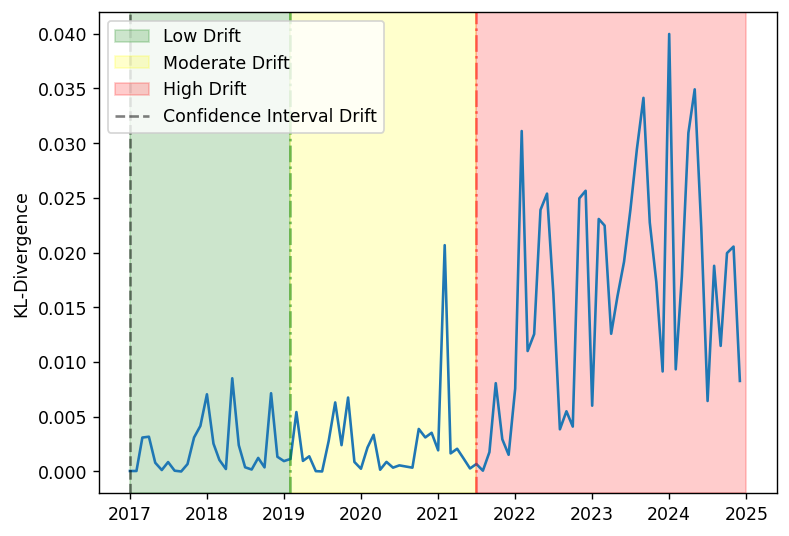

In [28]:
import matplotlib.pyplot as plt
plt.plot(diverge)
plt.ylabel('KL-Divergence')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(pred_rfr.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_rfr.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.legend()

In [29]:
mae_threshold = ForecastingHelpers.compute_mae(y_val, pred_mapie)*0.9
mae_drift = (np.abs(sampled_pred - test_m)).cumsum()/len(test_m)
rmse_drift = np.sqrt(((sampled_pred - test_m).cumsum()**2)/len(test_m))
mae_point = mae_drift.index[mae_drift.searchsorted(mae_threshold)]
rmse_threshold = np.sqrt(np.mean((y_val - pred_mapie) ** 2))*0.9
rmse_point = rmse_drift.index[rmse_drift.searchsorted(rmse_threshold)]

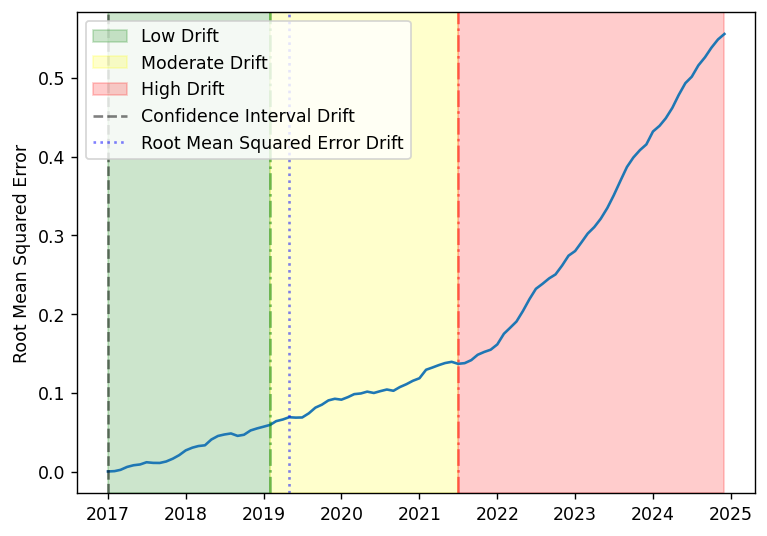

In [30]:
plt.plot(rmse_drift)
plt.ylabel('Root Mean Squared Error')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(sampled_pred.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,sampled_pred.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.axvline(x=rmse_point, color="blue", alpha=0.5, linestyle=":", label="Root Mean Squared Error Drift")
plt.legend();

In [31]:
print(div)
print(med_drift)
print(rmse_point)

2017-01-01 01:00:00
2019-02-01 00:00:00
2019-05-01 00:00:00


In [32]:
print(sampled_pred.index[0])

2017-01-01 00:00:00
